# PATIA : Courbe des performances relatives de chaque méthode de recherche

In [1]:
from solve_npuzzle import solve_bfs, solve_dfs, solve_astar, solve_iddfs, load_puzzle, Node
import time
import math

# Timeout
import signal

# Register an handler for the timeout
def handler(signum, frame):
    raise Exception("end of time")

# Register the signal function handler
signal.signal(signal.SIGALRM, handler)

algos_solve_methods = {
    "BFS": lambda open: solve_bfs(open),
    "DFS": lambda open: solve_dfs(open),
    "IDDFS": lambda open: solve_iddfs(open[0], 100),
    "A*": lambda open: solve_astar(open)
}
test_files = ["easy/npuzzle_3x3_len3_2.txt", "medium/npuzzle_5x5_len5_2.txt", "hard/npuzzle_10x10_len9_2.txt", "extreme/npuzzle_12x12_len15_2.txt", "impossible/npuzzle_15x15_len40_2.txt"]

result = []
i = 0
for name , solver in algos_solve_methods.items():
    result.append([])
    for file in test_files:

        puzzle = load_puzzle("tests/" + file)

        root = Node(state = puzzle, move = None)
        open = [root]

        # 120 seconds alarm
        signal.alarm(30)
        try:
            start_time = time.time()
            solution = solver(open)
            duration = time.time() - start_time
        except Exception:
            duration = math.inf
        result[i].append(duration)
        print(duration)
    i += 1
print(result)

8.130073547363281e-05
0.022708892822265625


2.6429378986358643


KeyboardInterrupt: 

/tmp/ipykernel_44343/2756986067.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[i].set_ylim(0, MAX_TIME)


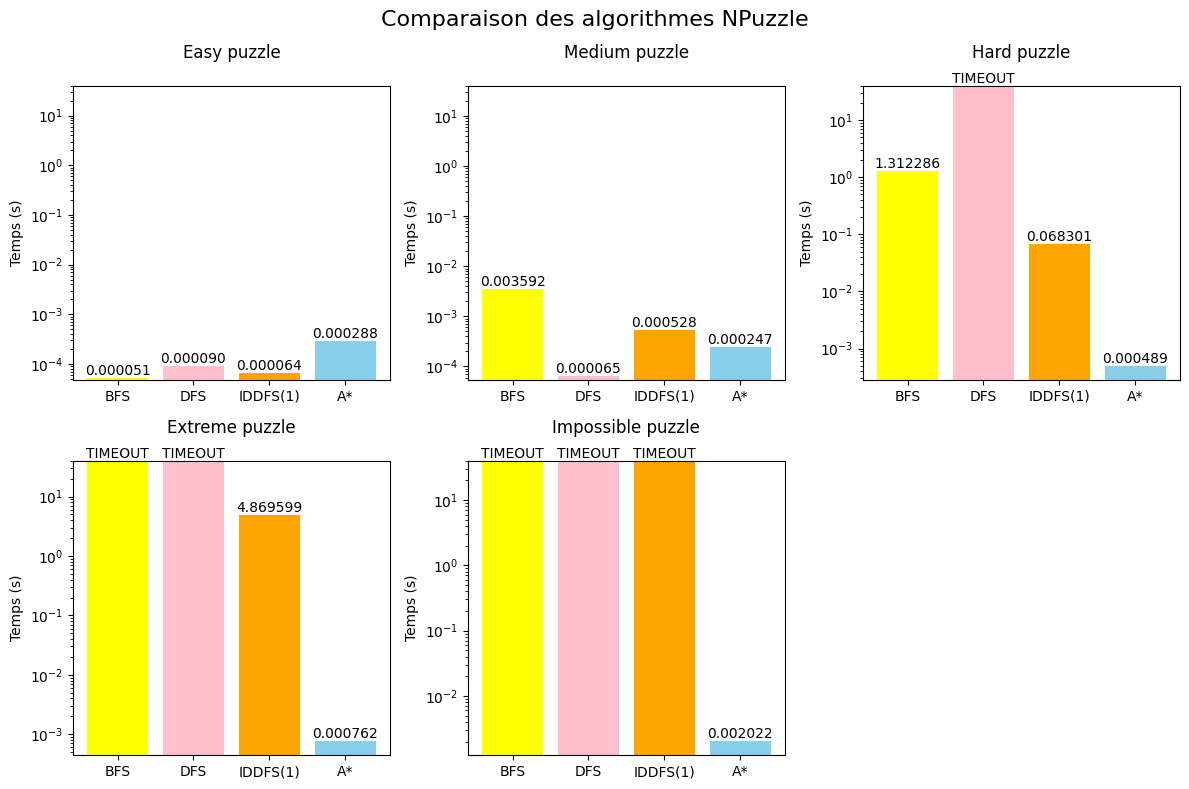

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/enzo/Desktop/M1/PATIA/PATIA-Work/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/enzo/Desktop/M1/PATIA/PATIA-Work/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/enzo/Desktop/M1/PATIA/PATIA-Work/venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/enzo/Desktop/M1/PATIA/PATIA-Work/venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever
    self._run_once()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 1949, in _run_once
    event_list = self._selector.select(timeout)
   

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

inf = math.inf
result = [[5.1021575927734375e-05, 0.0035920143127441406, 1.312286376953125, inf, inf], [9.036064147949219e-05, 6.4849853515625e-05, inf, inf, inf], [6.437301635742188e-05, 0.0005276203155517578, 0.06830072402954102, 4.869598865509033, inf], [0.00028777122497558594, 0.0002472400665283203, 0.0004892349243164062, 0.0007624626159667969, 0.00202178955078125]]
algos = ["BFS", "DFS", "IDDFS(1)", "A*"]
difficulties = ["Easy", "Medium", "Hard", "Extreme", "Impossible"]

MAX_TIME = 40
result_clean = [
    [min(x, MAX_TIME) for x in algo] for algo in result
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.delaxes(axes[1,2]) # The indexing is zero-based here
axes = axes.flatten()

for i, diff in enumerate(difficulties):
    times = [result_clean[j][i] for j in range(len(algos))]
    
    bars = axes[i].bar(algos, times, color=['yellow', 'pink', 'orange', 'skyblue'])
    
    axes[i].set_title(f"{diff} puzzle", pad=20)
    axes[i].set_yscale('log')
    axes[i].set_ylabel("Temps (s)")
    axes[i].set_ylim(0, MAX_TIME)

    for bar, val in zip(bars, times):
        label = "TIMEOUT" if val == MAX_TIME else f"{val:.6f}"
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height(), label, ha='center', va='bottom')

plt.suptitle("Comparaison des algorithmes NPuzzle", fontsize=16)
plt.tight_layout()
plt.show()